Total pacientes en dataset: 1025
Pacientes para entrenar (70%): 717
Pacientes para testear (30%): 308

PASO 1: REGRESIÓN LOGÍSTICA (CURVA EMPÍRICA)
-> AUC Empírico Obtenido: 0.8995



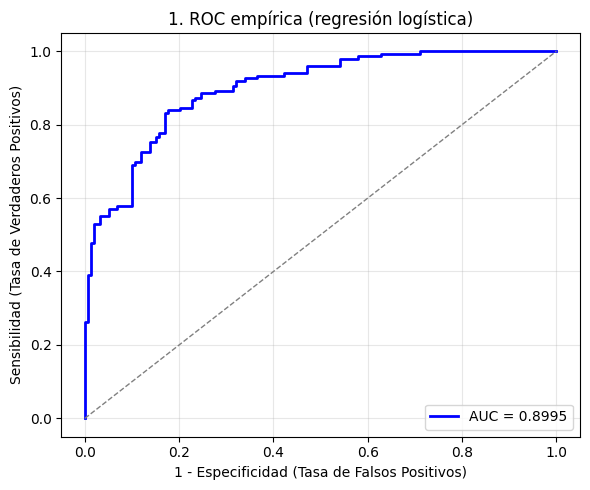

PASO 2: REGRESIÓN LOGÍSTICA (ASUNCIÓN BINORMAL)
-> Estadísticos calculados asumiendo Normalidad:
   Sanos (y=0):   Media = 0.2580, Desv. Est. = 0.2955
   Enfermos (y=1): Media = 0.7808, Desv. Est. = 0.2515

-> AUC Teórico Binormal: 0.9110



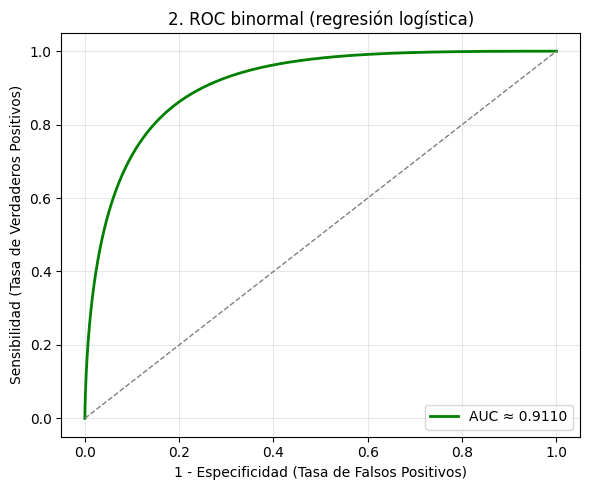

-> Generando gráfico de las Campanas de Gauss...


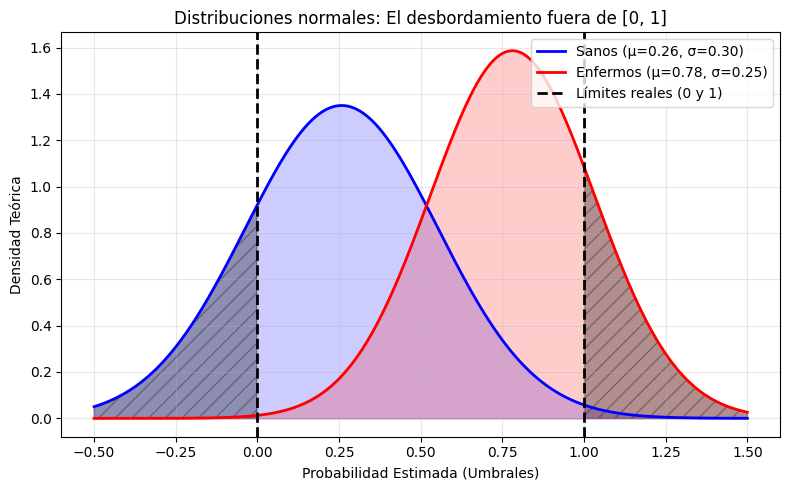

PASO 3: ÁRBOL DE DECISIÓN
-> AUC Árbol de Decisión Obtenido: 0.9334



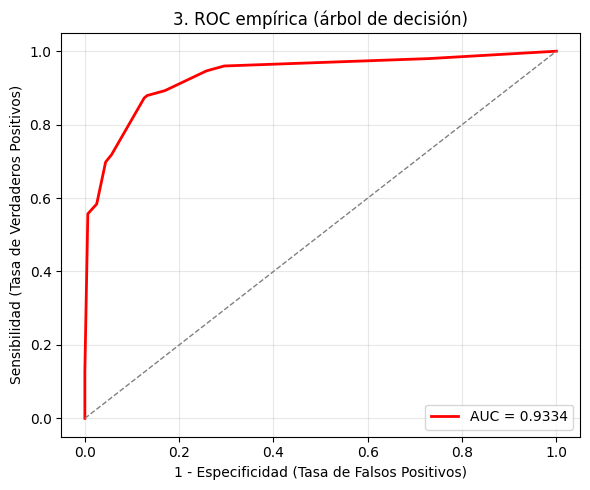

PASO 4: ESTRUCTURA INTERNA DEL ÁRBOL


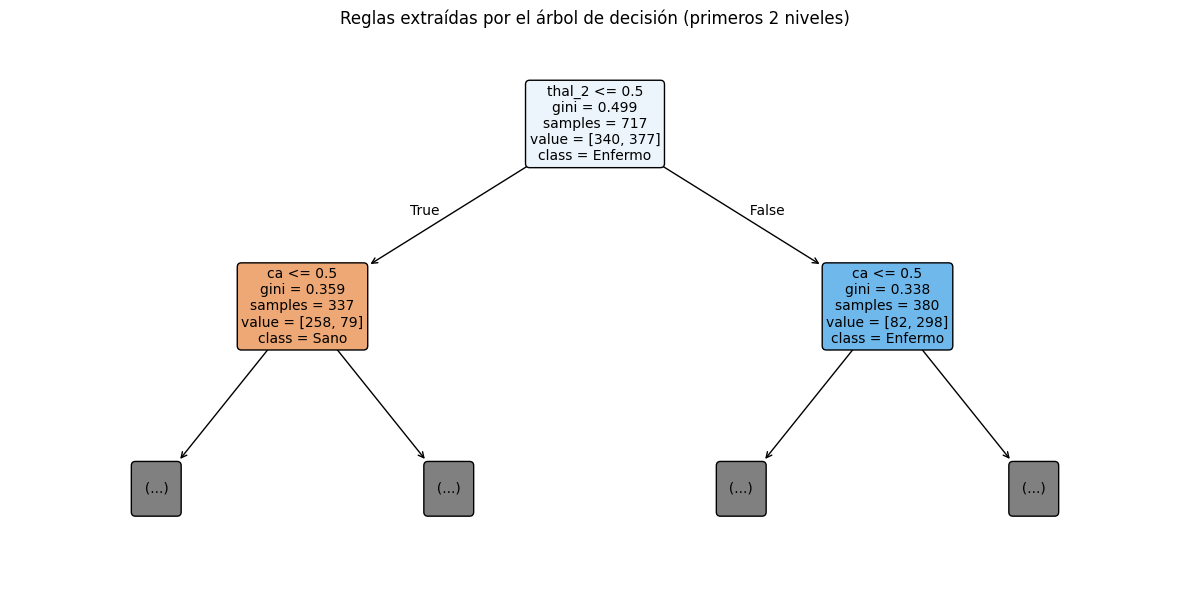

PASO 5: ÍNDICE DE YOUDEN Y YOUDEN GENERALIZADO
-> Prevalencia (p): 0.4838
-> Ratio de Costes (C_FP/C_FN): 0.2
-> Parámetro r: 0.2134

=== 1. Reg. Logística (Empírica) ===
  ESTÁNDAR (J): Max = 0.6628
    - Umbral Óptimo: > 0.6220
    - Consigue: Sensibilidad = 0.8389 | Especificidad = 0.8239
  GENERALIZADO (Jr con r=0.21): Max = 0.0779
    - Nuevo Umbral: > 0.0735
    - Consigue: Sensibilidad = 0.9799 | Especificidad = 0.4591

=== 2. Reg. Logística (Binormal) ===
  ESTÁNDAR (J): Max = 0.6625
    - Umbral Óptimo: > 0.4835
    - Consigue: Sensibilidad = 0.8534 | Especificidad = 0.8091
  GENERALIZADO (Jr con r=0.21): Max = 0.0910
    - Nuevo Umbral: > 0.6847
    - Consigue: Sensibilidad = 0.9679 | Especificidad = 0.5769

=== 3. Árbol de Decisión ===
  ESTÁNDAR (J): Max = 0.7471
    - Umbral Óptimo: > 0.6000
    - Consigue: Sensibilidad = 0.8792 | Especificidad = 0.8679
  GENERALIZADO (Jr con r=0.21): Max = 0.1101
    - Nuevo Umbral: > 0.1739
    - Consigue: Sensibilidad = 0.9597 | Especif

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm
import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning
# Se deshabilitan warnings de convergencia del solver LBFGS.
# Se prioriza no estandarizar para mantener la interpretabilidad de las variables.
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# PASO 0: PREPARACIÓN DE DATOS
df = pd.read_csv('heart.csv')
cat_vars = ['cp', 'restecg', 'slope', 'thal']
df_final = pd.get_dummies(df, columns=cat_vars, drop_first=True)
X = df_final.drop('target', axis=1)
y = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Total pacientes en dataset: {len(df)}")
print(f"Pacientes para entrenar (70%): {len(X_train)}")
print(f"Pacientes para testear (30%): {len(X_test)}\n")

# PASO 1: REGRESIÓN LOGÍSTICA (CURVA EMPÍRICA)
print("="*50)
print("PASO 1: REGRESIÓN LOGÍSTICA (CURVA EMPÍRICA)")
print("="*50)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_prob_log = log_reg.predict_proba(X_test)[:, 1]

fpr_emp, tpr_emp, thresholds_emp = roc_curve(y_test, y_prob_log)
roc_auc_emp = auc(fpr_emp, tpr_emp)

print(f"-> AUC Empírico Obtenido: {roc_auc_emp:.4f}\n")

# Gráfico
plt.figure(figsize=(6, 5))
plt.plot(fpr_emp, tpr_emp, color='blue', lw=2, label=f'AUC = {roc_auc_emp:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('1. ROC empírica (regresión logística)')
plt.xlabel('1 - Especificidad (Tasa de Falsos Positivos)')
plt.ylabel('Sensibilidad (Tasa de Verdaderos Positivos)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PASO 2: REGRESIÓN LOGÍSTICA ( BINORMAL)
print("="*50)
print("PASO 2: REGRESIÓN LOGÍSTICA (ASUNCIÓN BINORMAL)")
print("="*50)

scores_0 = y_prob_log[y_test == 0]  # Sanos
scores_1 = y_prob_log[y_test == 1]  # Enfermos


mu_0, std_0 = np.mean(scores_0), np.std(scores_0)
mu_1, std_1 = np.mean(scores_1), np.std(scores_1)

print("-> Estadísticos calculados asumiendo Normalidad:")
print(f"   Sanos (y=0):   Media = {mu_0:.4f}, Desv. Est. = {std_0:.4f}")
print(f"   Enfermos (y=1): Media = {mu_1:.4f}, Desv. Est. = {std_1:.4f}\n")

thresholds_binorm = np.linspace(-1, 2, 1000)
fpr_binorm = 1 - norm.cdf(thresholds_binorm, mu_0, std_0)
tpr_binorm = 1 - norm.cdf(thresholds_binorm, mu_1, std_1)

valid_idx = ~np.isnan(fpr_binorm) & ~np.isnan(tpr_binorm)
fpr_binorm, tpr_binorm = fpr_binorm[valid_idx], tpr_binorm[valid_idx]
sort_idx = np.argsort(fpr_binorm)
fpr_binorm, tpr_binorm = fpr_binorm[sort_idx], tpr_binorm[sort_idx]

roc_auc_binorm = auc(fpr_binorm, tpr_binorm)
print(f"-> AUC Teórico Binormal: {roc_auc_binorm:.4f}\n")

# Gráfico
plt.figure(figsize=(6, 5))
plt.plot(fpr_binorm, tpr_binorm, color='green', lw=2, label=f'AUC ≈ {roc_auc_binorm:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('2. ROC binormal (regresión logística)')
plt.xlabel('1 - Especificidad (Tasa de Falsos Positivos)')
plt.ylabel('Sensibilidad (Tasa de Verdaderos Positivos)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# EXTRA: VISUALIZACIÓN DE LAS CAMPANAS DE GAUSS
print("-> Generando gráfico de las Campanas de Gauss...")

x_campanas = np.linspace(-0.5, 1.5, 1000)

pdf_sanos = norm.pdf(x_campanas, mu_0, std_0)
pdf_enfermos = norm.pdf(x_campanas, mu_1, std_1)

plt.figure(figsize=(8, 5))

plt.plot(x_campanas, pdf_sanos, color='blue', lw=2, label=f'Sanos (μ={mu_0:.2f}, σ={std_0:.2f})')
plt.plot(x_campanas, pdf_enfermos, color='red', lw=2, label=f'Enfermos (μ={mu_1:.2f}, σ={std_1:.2f})')

plt.fill_between(x_campanas, pdf_sanos, alpha=0.2, color='blue')
plt.fill_between(x_campanas, pdf_enfermos, alpha=0.2, color='red')

plt.axvline(0, color='black', linestyle='--', lw=2, label='Límites reales (0 y 1)')
plt.axvline(1, color='black', linestyle='--', lw=2)

plt.fill_between(x_campanas, pdf_sanos, where=(x_campanas < 0), color='black', alpha=0.3, hatch='//')
plt.fill_between(x_campanas, pdf_enfermos, where=(x_campanas > 1), color='black', alpha=0.3, hatch='//')

plt.title('Distribuciones normales: El desbordamiento fuera de [0, 1]')
plt.xlabel('Probabilidad Estimada (Umbrales)')
plt.ylabel('Densidad Teórica')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PASO 3: ÁRBOL DE DECISIÓN (CURVA EMPÍRICA)
print("="*50)
print("PASO 3: ÁRBOL DE DECISIÓN")
print("="*50)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

print(f"-> AUC Árbol de Decisión Obtenido: {roc_auc_dt:.4f}\n")

# Gráfico
plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label=f'AUC = {roc_auc_dt:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.title('3. ROC empírica (árbol de decisión)')
plt.xlabel('1 - Especificidad (Tasa de Falsos Positivos)')
plt.ylabel('Sensibilidad (Tasa de Verdaderos Positivos)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

from sklearn.tree import plot_tree

# PASO 4: VISUALIZAR EL ÁRBOL DE DECISIÓN
print("="*50)
print("PASO 4: ESTRUCTURA INTERNA DEL ÁRBOL")
print("="*50)

plt.figure(figsize=(12, 6))

plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Sano', 'Enfermo'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=1)

plt.title("Reglas extraídas por el árbol de decisión (primeros 2 niveles)")
plt.tight_layout()

plt.savefig('arbol_entrenado_tfg.png', dpi=300)
plt.show()

# PASO 5: ÍNDICE DE YOUDEN Y YOUDEN GENERALIZADO
print("="*50)
print("PASO 5: ÍNDICE DE YOUDEN Y YOUDEN GENERALIZADO")
print("="*50)

p = np.mean(y_test)
C_FP = 1
C_FN = 5
r = ((1 - p) / p) * (C_FP / C_FN)

print(f"-> Prevalencia (p): {p:.4f}")
print(f"-> Ratio de Costes (C_FP/C_FN): {C_FP/C_FN}")
print(f"-> Parámetro r: {r:.4f}\n")

def calc_youden(fpr, tpr, thresh, name):

    especificidad = 1 - fpr

    J = tpr + especificidad - 1
    best_idx = np.argmax(J)

    Jr = tpr + r * especificidad - 1
    best_idx_r = np.argmax(Jr)

    return {
        'name': name,
        'J_max': J[best_idx], 'tpr_J': tpr[best_idx], 'esp_J': especificidad[best_idx], 'th_J': thresh[best_idx],
        'Jr_max': Jr[best_idx_r], 'tpr_Jr': tpr[best_idx_r], 'esp_Jr': especificidad[best_idx_r], 'th_Jr': thresh[best_idx_r]
    }

res_emp = calc_youden(fpr_emp, tpr_emp, thresholds_emp, "1. Reg. Logística (Empírica)")
res_binorm = calc_youden(fpr_binorm, tpr_binorm, thresholds_binorm, "2. Reg. Logística (Binormal)")
res_dt = calc_youden(fpr_dt, tpr_dt, thresholds_dt, "3. Árbol de Decisión")

for res in [res_emp, res_binorm, res_dt]:
    print(f"=== {res['name']} ===")
    print(f"  ESTÁNDAR (J): Max = {res['J_max']:.4f}")
    print(f"    - Umbral Óptimo: > {res['th_J']:.4f}")
    print(f"    - Consigue: Sensibilidad = {res['tpr_J']:.4f} | Especificidad = {res['esp_J']:.4f}")

    print(f"  GENERALIZADO (Jr con r={r:.2f}): Max = {res['Jr_max']:.4f}")
    print(f"    - Nuevo Umbral: > {res['th_Jr']:.4f}")
    print(f"    - Consigue: Sensibilidad = {res['tpr_Jr']:.4f} | Especificidad = {res['esp_Jr']:.4f}\n")

joblib.dump(dt_model, 'modelo_arbol.pkl')
print("Modelo del arbol guardado correctamente.")

from sklearn.metrics import confusion_matrix

# PASO 6: MATRIZ DE CONFUSIÓN (ÁRBOL DE DECISIÓN)
umbral_optimo = res_dt['th_Jr']

y_pred_optimo = (y_prob_dt >= umbral_optimo).astype(int)

cm_optimo = confusion_matrix(y_test, y_pred_optimo)
VN_opt, FP_opt, FN_opt, VP_opt = cm_optimo.ravel()

print(f"Resultados con el umbral óptimo de Youden (> {umbral_optimo:.4f}):")
print(f"-> Verdaderos Positivos (VP): {VP_opt}")
print(f"-> Verdaderos Negativos (VN): {VN_opt}")
print(f"-> Falsos Positivos (FP): {FP_opt}")
print(f"-> Falsos Negativos (FN): {FN_opt}")

umbral_estandar = 0.5

y_pred_est = (y_prob_dt >= umbral_estandar).astype(int)

cm_est = confusion_matrix(y_test, y_pred_est)
VN_opt, FP_opt, FN_opt, VP_opt = cm_est.ravel()

print(f"Resultados con el umbral estándar (> {umbral_estandar:.4f}):")
print(f"-> Verdaderos Positivos (VP): {VP_opt}")
print(f"-> Verdaderos Negativos (VN): {VN_opt}")
print(f"-> Falsos Positivos (FP): {FP_opt}")
print(f"-> Falsos Negativos (FN): {FN_opt}")